## Image Compression with SVD

Adapted from : Data-Driven Science and Engineering, Brunton and Kutz, Chapter 2

Link: https://faculty.washington.edu/sbrunton/databookRL.pdf


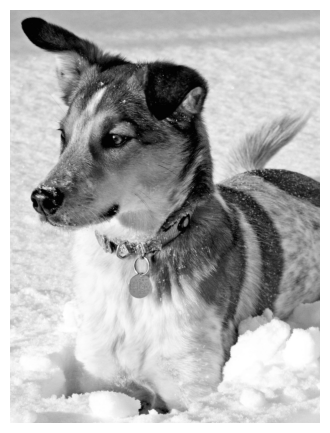

In [ ]:
from matplotlib.image import imread
import matplotlib.pyplot as plt
import numpy as np
import os
plt.rcParams['figure.figsize'] = [4, 7]


A = imread('dog.jpg')
X = np.mean(A, -1); # Convert RGB to grayscale

img = plt.imshow(X)
img.set_cmap('gray')
plt.axis('off')
plt.show()

In [2]:
# X = X.T
U_tild, S_t, VT_tild = np.linalg.svd(X, full_matrices=False)
S_tild = np.diag(S_t)

In [3]:
print(U_tild.shape)
print(S_tild.shape)
print(VT_tild.shape)

(2000, 1500)
(1500, 1500)
(1500, 1500)


In [4]:
U, S, VT = np.linalg.svd(X,full_matrices=True)
S = np.diag(S)

print(U.shape)
print(S.shape)
print(VT.shape)

(2000, 2000)
(1500, 1500)
(1500, 1500)


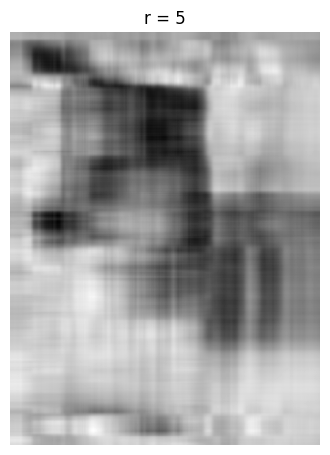

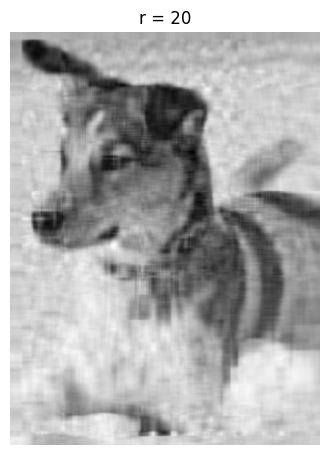

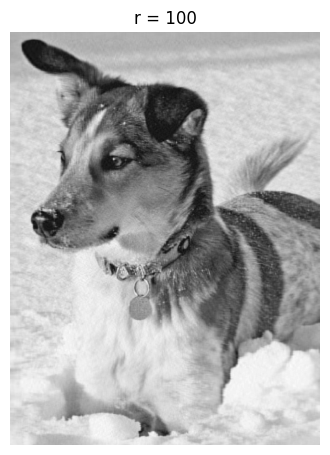

In [5]:
%matplotlib inline

j = 0
for r in (5, 20, 100):
    # Construct approximate image
    Xapprox = U[:,:r] @ S[0:r,:r] @ VT[:r,:]
    plt.figure(j+1, figsize=(4, 7))
    j += 1
    img = plt.imshow(Xapprox)
    img.set_cmap('gray')
    plt.axis('off')
    plt.title('r = ' + str(r))
    plt.show()

In [6]:
r = 20
print('x', X.shape)
print('u', U[:, :r].shape)
print('s', S[:r, :r].shape)
print('vt', VT[:r, :].shape)

x (2000, 1500)
u (2000, 20)
s (20, 20)
vt (20, 1500)


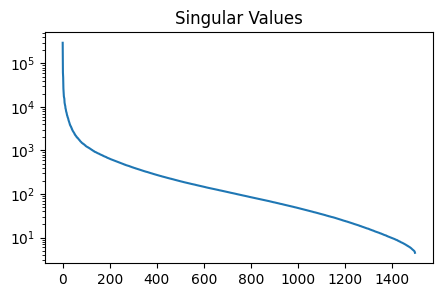

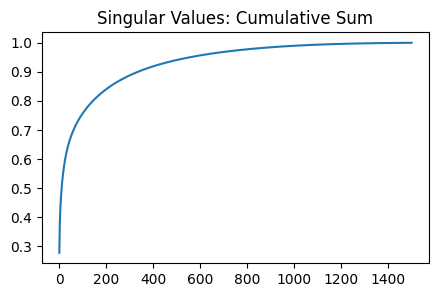

In [7]:


plt.figure(1, figsize=(5, 3))
plt.semilogy(np.diag(S))
plt.title('Singular Values')
plt.show()

plt.figure(2, figsize=(5, 3))
plt.plot(np.cumsum(np.diag(S))/np.sum(np.diag(S)))
plt.title('Singular Values: Cumulative Sum')
plt.show()